<a href="https://colab.research.google.com/github/mikadishen/Guara2_lotes_vagos/blob/main/S2DR4_Inferencia_V4_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gamma Earth S2DR4 - Sentinel-2 Deep Resolution 4.0
## Super-resolução de Imagem Única de 10 Bandas e 10x para Sentinel-2 Eficaz

Este notebook demonstra o desempenho do módulo S2DR4. A descrição detalhada do módulo, bem como a análise de desempenho, podem ser encontradas no seguinte white paper. Entre em contato com info@gamma.earth para funcionalidades estendidas, uso comercial e outras consultas.

O módulo S2DR4 buscará dados do Sentinel-2 para o local e data fornecidos e aplicará super-resolução nas 10 bandas multiespectrais, passando da resolução original de 10m e 20m para a resolução espacial alvo de 1m/px. O resultado é uma imagem TIF georreferenciada multiespectral de 10 bandas e 1m/px. O produto de saída será gerado no caminho do sistema de arquivos local '/content/output' localizado aqui:


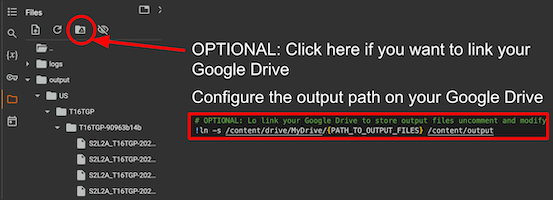

A saída conterá 4 produtos:

S2L2Ax10_T[MGRS]-[UID]-[DATE]_MS.tif – Imagem multiespectral de 10 bandas

S2L2Ax10_T[MGRS]-[UID]-[DATE]_TCI.tif – Imagem RGB de cor verdadeira

S2L2Ax10_T[MGRS]-[UID]-[DATE]_NDVI.tif – Imagem NDVI em falsa cor

S2L2Ax10_T[MGRS]-[UID]-[DATE]_IRP.tif – Imagem infravermelha em falsa cor

A ordem das 10 bandas no produto multiespectral é: B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12.

# Instalação

In [1]:
# 1. Instalação do módulo S2DR4 (Core)
!pip -q install https://storage.googleapis.com/0x7ff601307fa5/s2dr4-20260205.1-cp312-cp312-linux_x86_64.whl

# 2. Instalação de dependências para manipulação de dados geoespaciais e GEE
# O rasterio é essencial para você ler as 10 bandas de 1m que o S2DR4 gera
!pip -q install earthengine-api rasterio geemap

# 3. Importação das bibliotecas no ambiente
import ee
import os
import rasterio
from google.colab import drive

print("Ambiente configurado com sucesso para S2DR4!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 115.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.3/254.3 kB 16.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 11.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Seleção automática da melhor imagem

**AUTENTICAÇÃO DO TOKEN**

In [5]:
!rm -rf /root/.config/earthengine

In [6]:
!earthengine authenticate

E0000 00:00:1772847012.662127    9047 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772847012.664879    9047 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772847012.671906    9047 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772847012.671922    9047 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772847012.671923    9047 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772847012.671925    9047 computation_placer.cc:177] computation placer already registered. Please check linka

# **LOGIN NO GOOGLE ENGINE**

In [7]:
import ee

ee.Initialize(project='sentinel1mdf')

print("Earth Engine conectado!")

Earth Engine conectado!


SELEÇÃO DE IMAGENS SENTINEL. OBS: SEMPRE AJUSTAR OS DOIS FILTER DATES PARA UMA BUSCA EFICAZ DAS DATAS

In [17]:
import ee

# Inicialização (autenticação já feita em outro bloco)
ee.Initialize(project='sentinel1mdf')

# Coordenadas (Brasília)
lon, lat = -48.0436552, -15.96442341
point = ee.Geometry.Point([lon, lat])

# Coleção Sentinel-2
collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(point)
    .filterDate('2025-01-01', '2025-03-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .sort('CLOUDY_PIXEL_PERCENTAGE')
)

# Número de imagens encontradas
n_images = collection.size().getInfo()

if n_images == 0:
    print("Nenhuma imagem com <20% de nuvens. Buscando a melhor disponível.")

    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(point)
        .filterDate('2025-01-01', '2025-03-31')
        .sort('CLOUDY_PIXEL_PERCENTAGE')
    )

# Seleciona a melhor imagem
image = collection.first()

# Data da imagem
date = ee.Image(image).date().format('YYYY-MM-dd').getInfo()

print("Melhor data:", date)

# Coordenadas para uso posterior (ex.: S2DR4)
lonlat = (lon, lat)

Melhor data: 2025-03-07


# Limpar saídas anteriores

In [18]:
#limpar o output
import shutil
import os

# Apaga o conteúdo antigo da pasta de saída
output_dir = '/content/output'
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

print("Pasta de saída limpa!")

Pasta de saída limpa!


# Inferencia

Preprocessing T22LHH-81682174b-20241023 (0)  done.
Preprocessing T22LHH-81682174b-20250307 (1) .............. done.
Preprocessing T22LHH-81682174b-20250304 (96) xxxxxxxxxxxxxx Alignment failed.
Preprocessing T22LHH-81682174b-20250227 (97) xxxxxxxxxxxxxx Alignment failed.
Preprocessing T22LHH-81682174b-20250225 (76) .....x..x..... done.
Preprocessing T22LHH-81682174b-20250205 (43) .............. done.
Preprocessing T22LHH-81682174b-20250126 (82) ..x.x.....xx.. done.
Preprocessing T22LHH-81682174b-20250123 (79) xxxxxxxxxxxxxx Alignment failed.
Preprocessing T22LHH-81682174b-20250121 (57) x..xx........x done.
Processing T22LHH-81682174b-20250307 . done.
Postprocessing T22LHH-81682174b-20250307 .....,..,.. done.

Find results at the following path: /content/output
Click the link below for preview:

https://gamayos.github.io/gamma-earth-api/s2dr4-sd-demo-01.html?ds=BR-T22LHH-81682174b-20250307#15/-15.9644/-48.0437



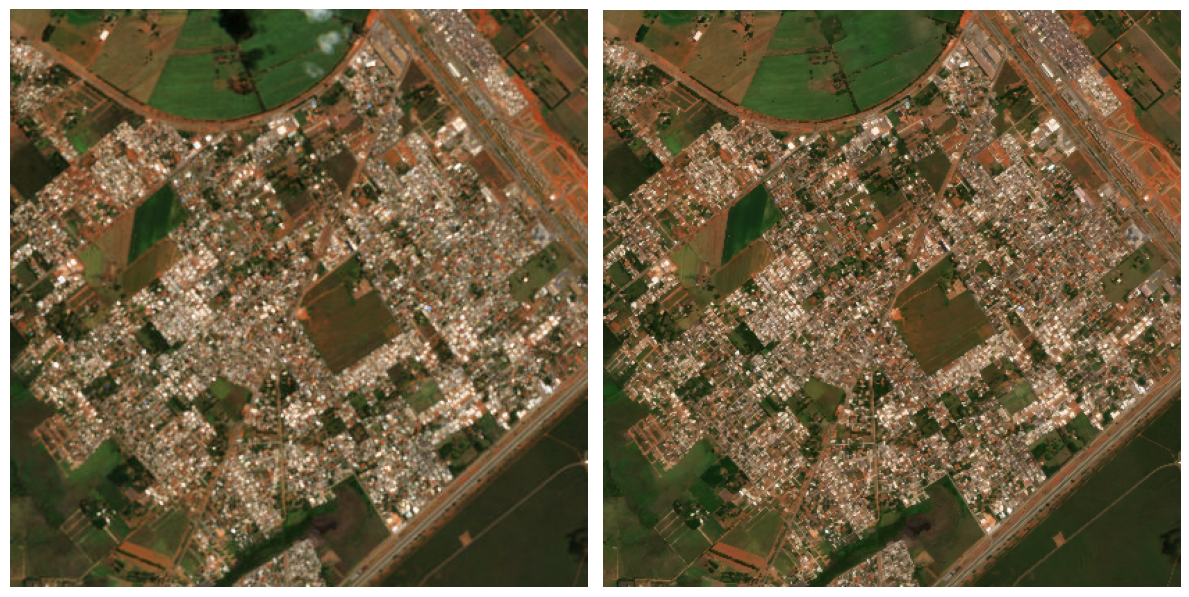

In [19]:
import s2dr4.inferutils

# Define a tupla de coordenadas no formato (Longitude, Latitude)
# utilizando as variáveis globais configuradas anteriormente.
lonlat = (lon, lat)

# Executa o processamento de super-resolução (S2DR4)
# O modelo buscará a cena do Sentinel-2 mais próxima da data filtrada
# e gerará os produtos de 1m/px no diretório /content/output
s2dr4.inferutils.test(lonlat=lonlat, date=date)

# Licença / License

**Copyright (c) Gamma Earth Sarl 2026**

O software é fornecido para fins de teste, avaliação de desempenho e validação. Todos os direitos são reservados pelo proprietário dos direitos autorais. Para funcionalidades estendidas e uso comercial, entre em contato com: **info@gamma.earth**

*The software is provided for testing, performance evaluation and validation. All rights are reserved by the copyright owner. For extended functionality and commercial use please contact info@gamma.earth*

---

### Como Citar / How to Cite

Para publicações acadêmicas ou relatórios técnicos relacionados ao uso do S2DR4, utilize a seguinte citação:

> Yosef Akhtman, S2DR4: Effective 10-Band 10x Single Image Super-Resolution for Sentinel-2. Medium: [https://medium.com/@ya_71389/c71a601a2253](https://medium.com/@ya_71389/c71a601a2253)

---

### Termos de Uso / Disclaimer

Observe que imagens de satélite selecionadas, geradas por usuários anônimos, podem ser reutilizadas para fins de divulgação.

**O SOFTWARE É FORNECIDO "COMO ESTÁ" (AS IS), SEM GARANTIA DE QUALQUER TIPO, EXPRESSA OU IMPLÍCITA, INCLUINDO, MAS NÃO SE LIMITANDO ÀS GARANTIAS DE COMERCIALIZAÇÃO, ADEQUAÇÃO A UM DETERMINADO FIM E NÃO VIOLAÇÃO. EM NENHUMA HIPÓTESE OS AUTORES OU DETENTORES DOS DIREITOS AUTORAIS SERÃO RESPONSÁVEIS POR QUALQUER RECLAMAÇÃO, DANOS OU OUTRA RESPONSABILIDADE, SEJA EM AÇÃO DE CONTRATO, ILÍCITO OU DE OUTRA FORMA, DECORRENTE DE, FORA DE OU EM CONEXÃO COM O SOFTWARE OU O USO OU OUTRAS NEGOCIAÇÕES NO SOFTWARE.**

*THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.*